Python Playground: Multivariate Normal

aus S. 24

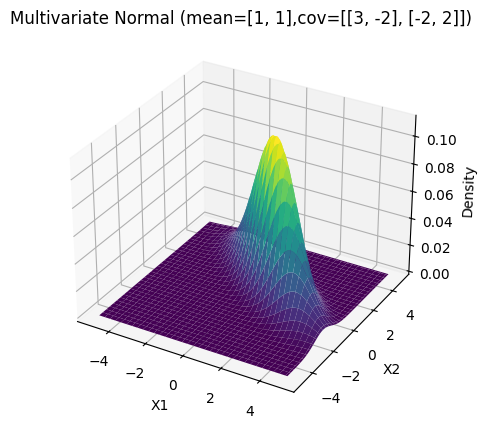

In [1]:
import numpy as np
import matplotlib.pyplot as plt
# (Optional import for older matplotlib versions)
from mpl_toolkits.mplot3d import Axes3D
# Step 1: Define the mean vector and covariance matrix
mu = np.array([1, 1]) # mean
Sigma = np.array([[3, -2], [-2, 2]]) # covariance matrix
# Step 2: Precompute determinant and inverse of the covariance matrix
detSigma = np.linalg.det(Sigma) # determinant |Sigma|
invSigma = np.linalg.inv(Sigma) # inverse Sigma^{-1}
# Step 3: Create a grid of (x1, x2) values over range [-5, 5] in each dim
x = np.linspace(-5, 5, 101) # 101 points from -5 to 5
y = np.linspace(-5, 5, 101)
X, Y = np.meshgrid(x, y) # create meshgrid matrices X and Y
# Step 4: Compute the bivariate Gaussian PDF value at each grid point
# …calculate (x - mu) for each point on the grid
# …form a 3D array 'pos' of shape (101, 101, 2) where the last dim. holds
# the vector [x1, x2]
pos = np.dstack((X, Y))
centered = pos - mu # subtract mean from each coordinate pair
# Compute the quadratic form (x-mu)^T * invSigma * (x-mu) for each point
# ...reshape grid of vectors to 2D array of shape (n*m, 2)
points = centered.reshape(-1, 2)
# ...apply (x - mu)^T @ invSigma @ (x - mu) for each point
quad_form = np.sum((points @ invSigma) * points, axis=1)
# ...reshape back to original grid shape (n, m)
exp_term = quad_form.reshape(centered.shape[:2])
# Calculate the normalization constant for 2D Gaussian
const = 1.0 / (2 * np.pi * np.sqrt(detSigma))
# Compute the PDF values matrix Z
Z = const * np.exp(-0.5 * exp_term)
# Step 5: Plot the result as a 3D surface
fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(111, projection='3d') # create 3D axes
ax.plot_surface(X, Y, Z, cmap='viridis', # surface plot with colormap
linewidth=0, antialiased=True)
# Step 6: Auto-scale the axes to fit the data (ensures the plot isn't truncated)
ax.axis('auto') # Matplotlib autoscaling (usually on by default)
# Step 7: Add title and labels
ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_zlabel('Density')
ax.set_title(f"Multivariate Normal (mean={mu.tolist()},cov={Sigma.tolist()})")
plt.show()